In [4]:
import networkx as nx
print(nx.__version__)

3.6.1


In [5]:
!pip install networkx


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import networkx as nx
print(nx.__version__)

3.6.1


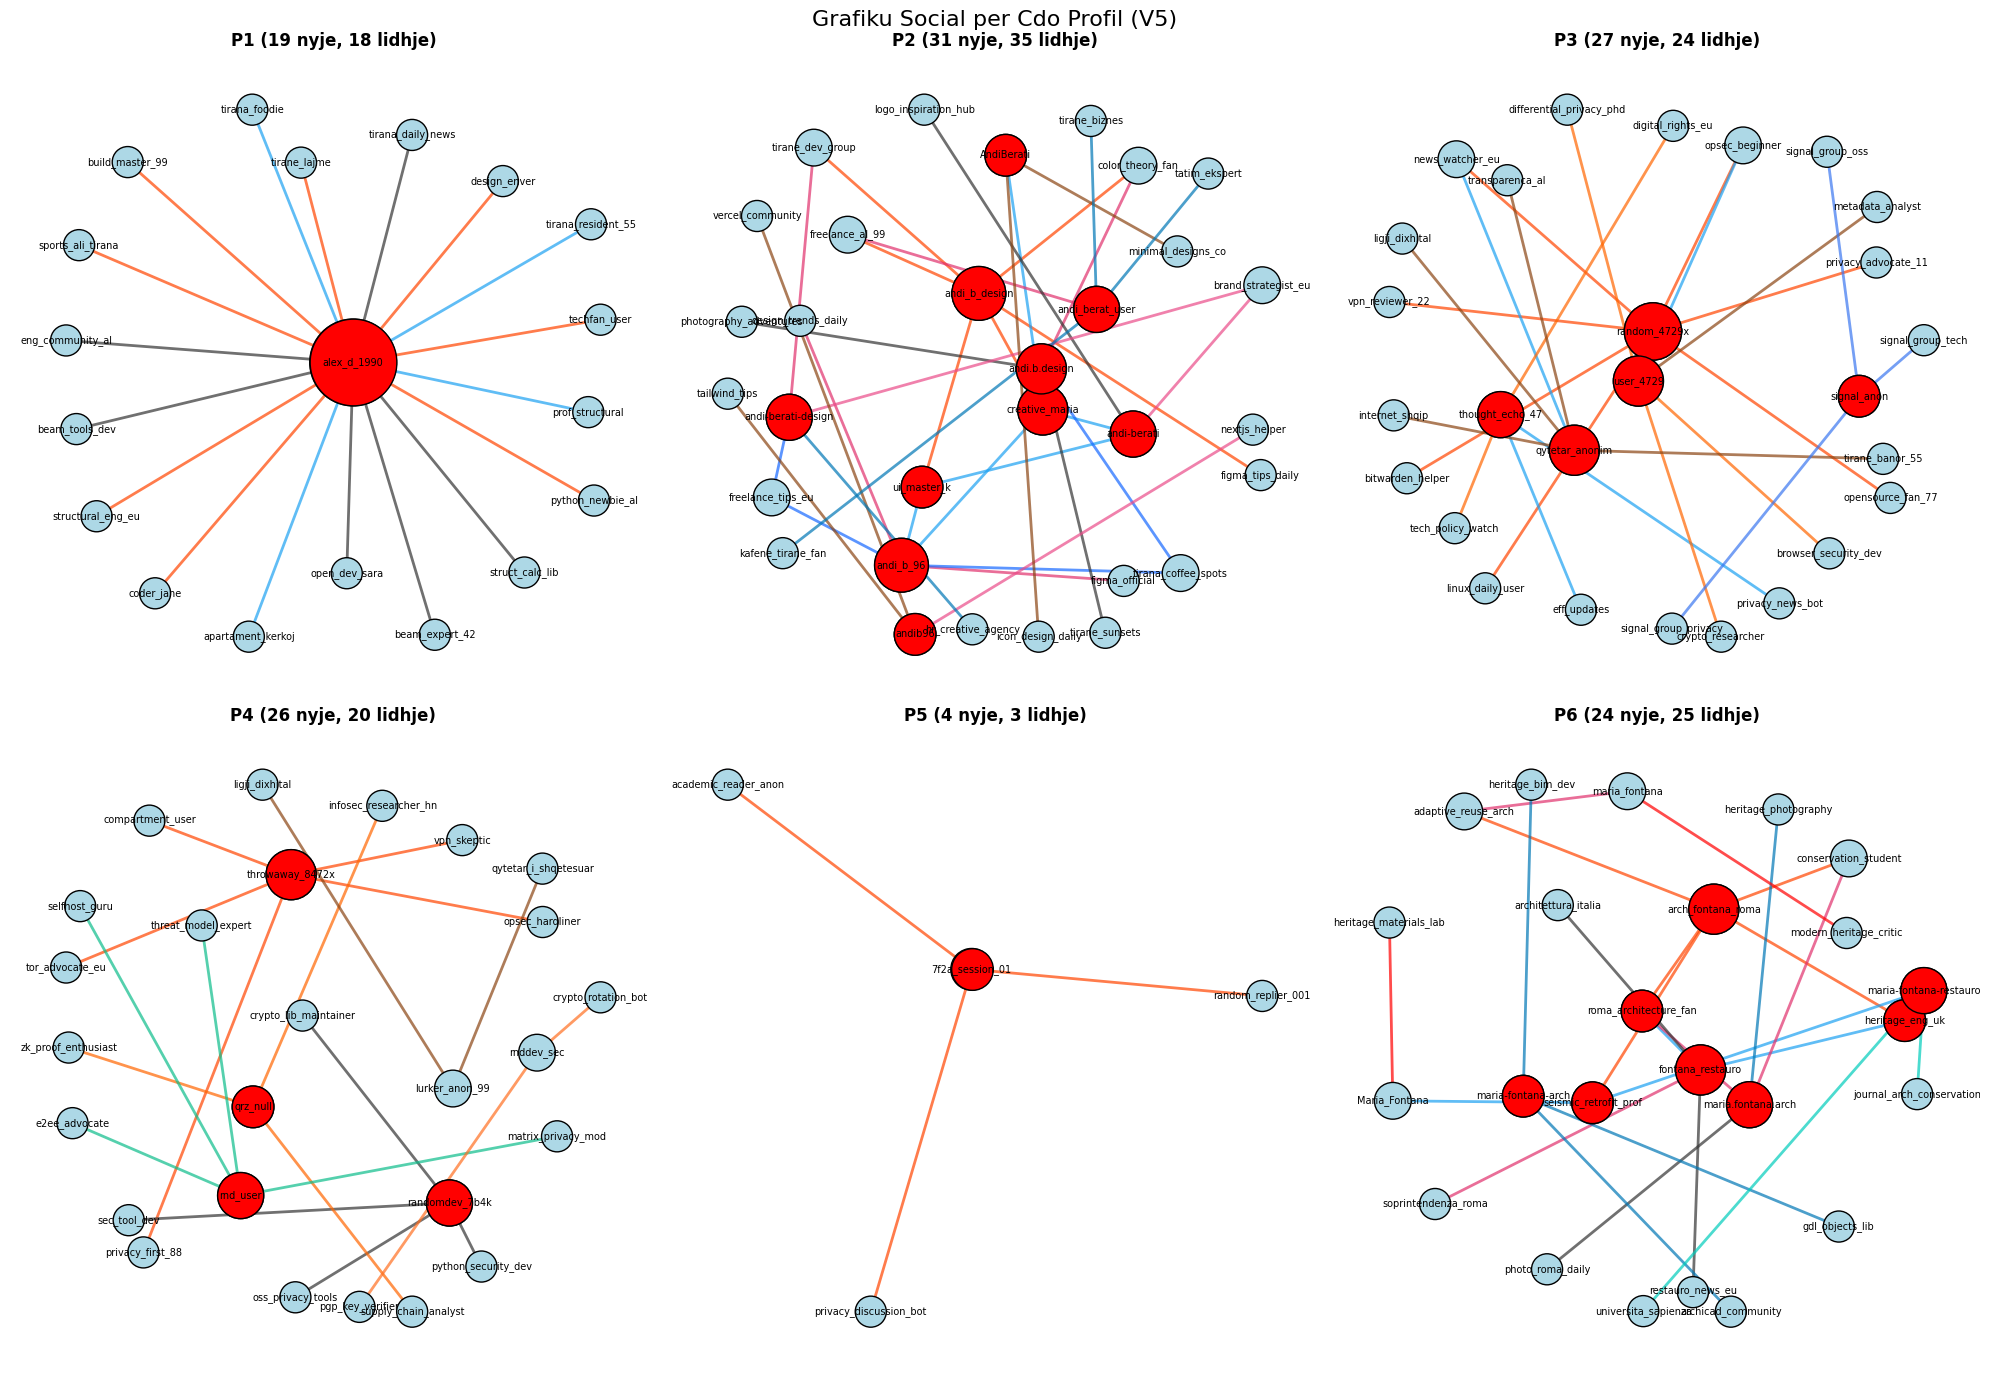

Figura e ruajtur ne figurat/V5_grafiku_social.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

base = r"C:\Users\Laura Biba\Desktop\OSINT Research\profile"
profiles = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Grafiku Social per Cdo Profil (V5)', fontsize=16)

colors_map = {
    'reddit': '#FF4500',
    'github': '#333333',
    'twitter': '#1DA1F2',
    'instagram': '#E1306C',
    'linkedin': '#0077B5',
    'stackoverflow': '#F48024',
    'medium': '#00AB6C',
    'forum_al': '#8B4513',
    'behance': '#1769FF',
    'dribbble': '#EA4C89',
    'hackernews': '#FF6600',
    'matrix': '#0DBD8B',
    'keybase': '#FF6F21',
    'signal': '#3A76F0',
    'researchgate': '#00CCBB',
    'archdaily': '#FF0000',
}

for i, profile in enumerate(profiles):
    ax = axes[i//3][i%3]
    path = os.path.join(base, profile, 'edges.csv')
    df = pd.read_csv(path)
    
    G = nx.Graph()
    edge_colors = []
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], platform=row['platform'], weight=int(row['weight']))
        edge_colors.append(colors_map.get(row['platform'], '#999999'))
    
    pos = nx.spring_layout(G, seed=42, k=2)
    
    node_sizes = [300 + G.degree(n) * 200 for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=2, alpha=0.7)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    
    bridges = [n for n in G.nodes() if G.degree(n) >= 3]
    if bridges:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=bridges, node_size=[300 + G.degree(n) * 200 for n in bridges], 
                              node_color='red', edgecolors='black')
    
    ax.set_title(f'{profile} ({len(G.nodes())} nyje, {len(G.edges())} lidhje)', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(base, '..', 'figurat', 'V5_grafiku_social.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figura e ruajtur ne figurat/V5_grafiku_social.png")